### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/var/folders/p8/pmrg399130j_1d148mx525q00000gn/T/ipykernel_1307/767131013.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


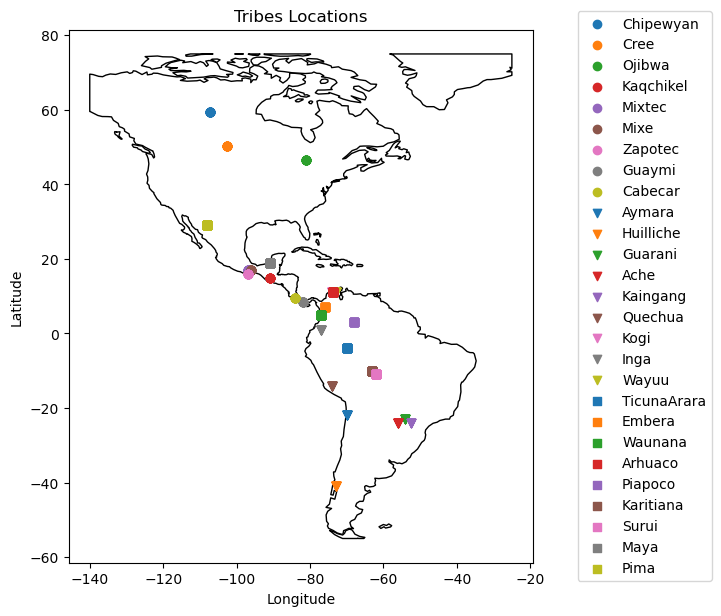

In [1]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

In [2]:
print(gdf.shape)

(494, 5718)


In [3]:
gdf.head()

,IndivID,PopID,Pop,Country,Continent,sex,lat,long,L1.125,L1.130,...,L677.259,L677.263,L677.267,L678.202,L678.206,L678.209.848101265823,L678.210,L678.214,L678.218,geometry
Chipewyan29,2012,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,1,0,0,POINT (-107.3 59.55)
Chipewyan31,2156,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,1,0,0,0,POINT (-107.3 59.55)
Chipewyan33,2381,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,1,0,0,0,0,POINT (-107.3 59.55)
Chipewyan35,2382,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,1,0,0,POINT (-107.3 59.55)
Chipewyan37,2383,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,1,0,0,0,0,0,1,0,0,POINT (-107.3 59.55)


<span style="color:blue">
<br>
    
The dataset `NAm2.txt` contains 494 people and 5718 columns. Most of the columns are genetic markers. People are associated with their location (latitude and longitude).

The code above starts by creating a DataFrame from `NAm2.txt`. Then it plots individuals according to their location on a cropped map  of the world (world.clip). Finally, the individuals are plotted on the map using different colors and markers depending on their tribe.
<br>

<span>

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [4]:
import numpy as np

In [5]:
# We get genetic makers as predictors
predictors = df.columns[8:]
X = df[predictors].to_numpy(dtype=float)

# We choose the latitude as y
y = df['long'].to_numpy(dtype=float)

# Compute XtX and Xty
XtX = X.T @ X
Xty = X.T @ y

try :
    beta_hat = np.linalg.solve(XtX, Xty)
    print("Value of beta_hat : ",  beta_hat)

except np.linalg.LinAlgError:
    print("Error while trying to compute beta_hat")

Error while trying to compute beta_hat


<span style="color:blue">
<br>
    
When trying to compute $\hat \beta$, a linear algebra error occurs. This happens because the number of predictors $p$ is much larger than the number of observations $N$. As a result, $ rank(X) < p$. Therefore, $X^TX$ is not invertible and the equation cannot be solved.

<br>

<span>

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [6]:
# Compute beta_hat
beta_hat = np.linalg.lstsq(X, y, rcond=None)[0]

<span style="color:blue">
<br>
    
The `linalg.lstsq` function does not actually solve $ X^TX \beta = X^T y$ . In fact, it minimizes $ || X \beta - y ||^2$. Unlike `linalg.solve`, the function `linalg.lstsq` does not require $X^TX$ to be invertible, which is not the case here.

<br>

<span>

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<span style="color:blue">
<br>

We try to solve the equation $ \quad y \quad =  \quad \beta_0 \quad +  \quad \beta_1 X_1  \quad + \quad ... \quad + \quad \beta_p X_p  \quad+ \quad \epsilon$. 

$\beta_0$ represents the expected value when all the predictors are zero, which would be unlikely to happen.

Like `linalg.lstsq`, the function `LinearRegression` relies on a least-squares solver that handles rank-deficient matrices. However, sklearn recenters the predictors before computing the coefficients, ensuring that the intercept represents the predicted value for an “average” individual and improves numerical stability. 

<br>

<span>

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

<span style="color:blue">
<br>

Principal Component Analysis (PCA) reduces the dimensionality of a dataset while keeping as much variance as possible. Geometrically, it finds new axes pointing in directions of maximum variance, and statistically, it creates uncorrelated components that summarize the information of the original variables.

<br>

<span>

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

In [9]:
from sklearn.decomposition import PCA

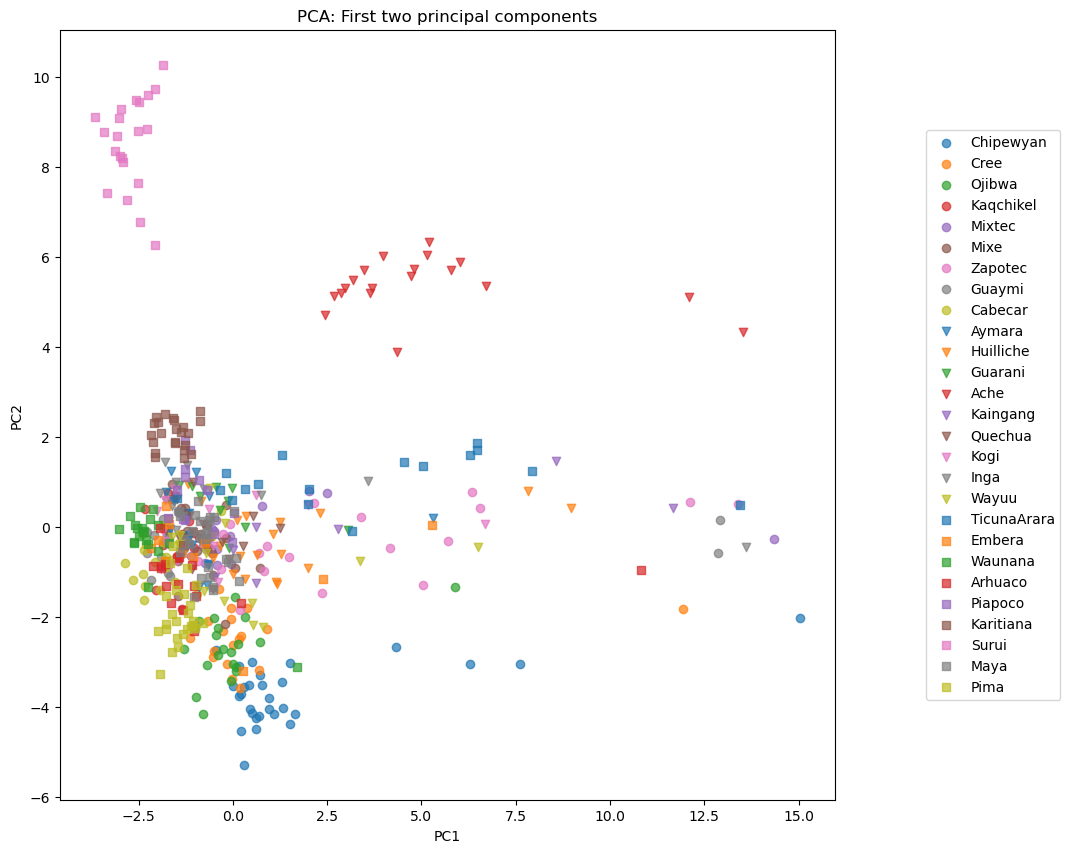

In [10]:
# PCA with 2 dimensions
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

# Colors and markers
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

plt.figure(figsize=(10, 10))

for i, tribe in enumerate(df['Pop'].unique()):
    tribe_indices = df['Pop'] == tribe

    plt.scatter(
        X_pca[tribe_indices, 0],
        X_pca[tribe_indices, 1],
        marker=marker_list[i//9],
        color=colors_list[i%9],
        label=tribe,
        alpha=0.7
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: First two principal components')
plt.legend(loc='center right', bbox_to_anchor=(1.3, 0.5))
plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

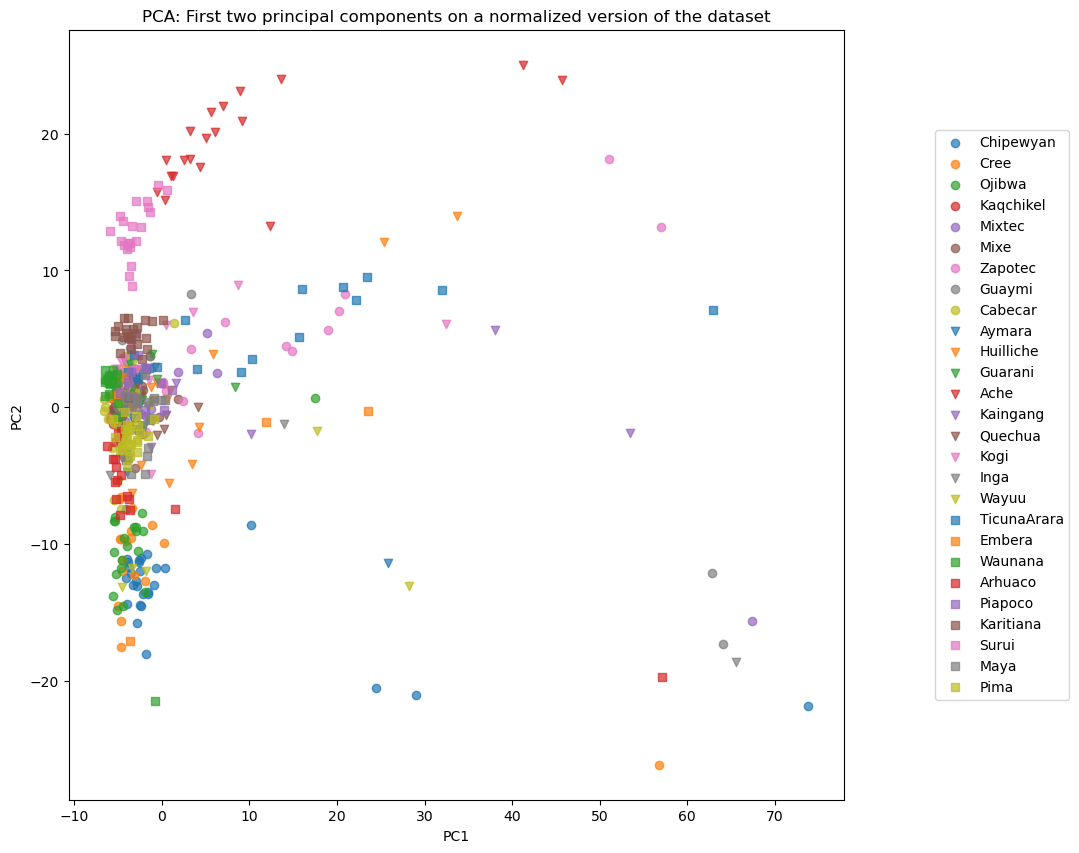

In [13]:
# PCA with 2 dimensions
pca = PCA(n_components = 2)
X_pca_std = pca.fit_transform(X_std)

# Colors and markers
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

plt.figure(figsize=(10, 10))

for i, tribe in enumerate(df['Pop'].unique()):
    tribe_indices = df['Pop'] == tribe

    plt.scatter(
        X_pca_std[tribe_indices, 0],
        X_pca_std[tribe_indices, 1],
        marker=marker_list[i//9],
        color=colors_list[i%9],
        label=tribe,
        alpha=0.7
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: First two principal components on a normalized version of the dataset')
plt.legend(loc='center right', bbox_to_anchor=(1.3, 0.5))
plt.show()

<span style="color:blue">
<br>

On the normalized version of the dataset, all markers contribute equally, regardless of their original variance. As a result, the clustering of individuals is different on this plot. 

<br>

<span>

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

<span style="color:blue">
<br>

Standardizing the data ensures that all genetic markers contribute equally to PCA. Thus, the genetic markers removes the dominance of high-variance markers in the PCA. As a result, the tribal clusters that were visible without standardization may disappear, indicating that the separation was mainly driven by a subset of highly variable markers rather than by all markers equally.

<br>

<span>

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.



Cumulative percentage of variance for first two components :  3.57 %



In order to get a cumulative percentage of variance over 85%, we have to use  309 principal components




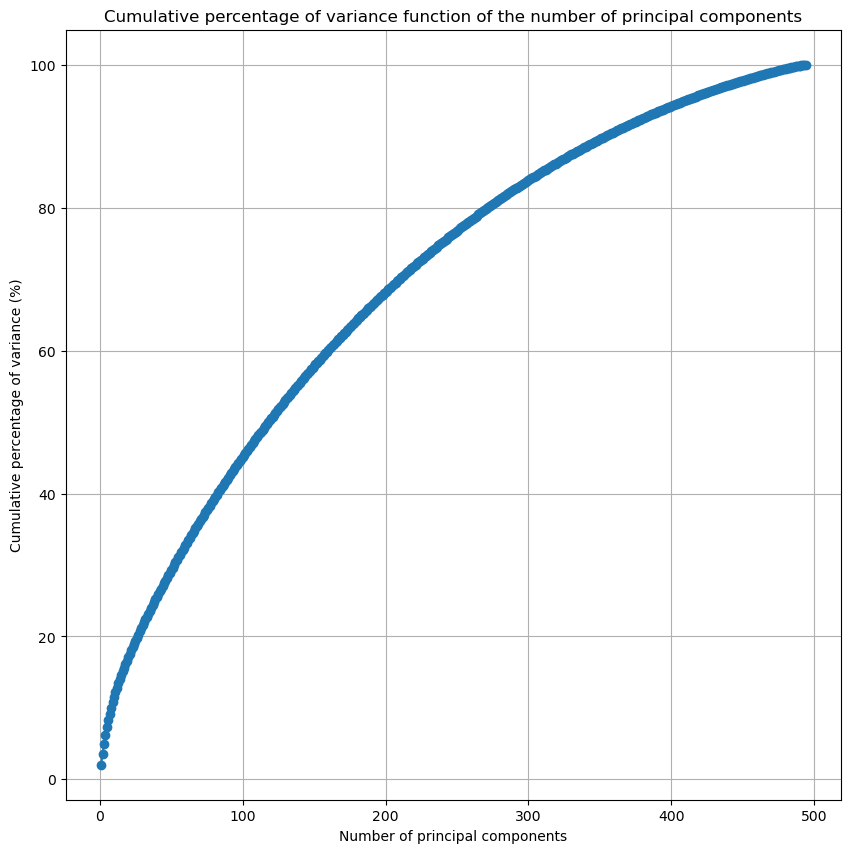

In [14]:
# PCA on standardized data
pca = PCA()
X_pca = pca.fit_transform(X) 

# Explained variance ratio
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Variance for first two components
variance_pc1_pc2 = round(cumulative_variance[1] * 100, 2)
print("\n")
print("Cumulative percentage of variance for first two components : ", variance_pc1_pc2,  "%\n")
print("\n")

# We want to get between 80 to 90 % of the variance to be captured, let's say 85%
components_for_variance_over_85 = np.argmax(cumulative_variance >= 0.85)
print("In order to get a cumulative percentage of variance over 85%, we have to use ", components_for_variance_over_85, "principal components")
print("\n")

plt.figure(figsize=(10, 10))
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance*100, marker='o')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative percentage of variance (%)')
plt.title('Cumulative percentage of variance function of the number of principal components')
plt.grid(True)
plt.show()

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

/var/folders/p8/pmrg399130j_1d148mx525q00000gn/T/ipykernel_1307/1402516160.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


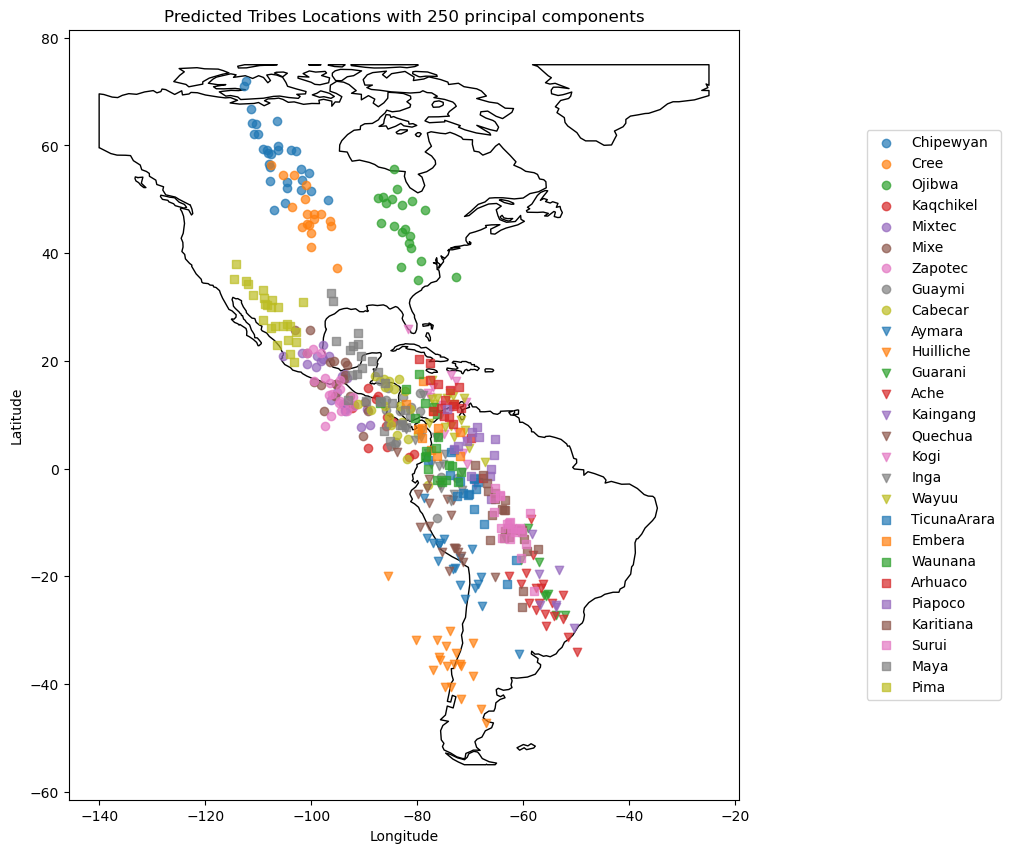

In [15]:
# PCA
pca = PCA(n_components = 250)
X_pca_250 = pca.fit_transform(X) 

# Latitude and Longitude
y = df[['lat', 'long']]
model = LinearRegression().fit(X_pca_250, y)
predictions = model.predict(X_pca_250)

# Figure
fig, ax = plt.subplots(figsize=(10, 10))
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

for i, tribe in enumerate(df['Pop'].unique()):
    tribe_mask = df['Pop'] == tribe
    ax.scatter(
        predictions[tribe_mask, 1],
        predictions[tribe_mask, 0],
        marker=marker_list[i//9],
        color=colors_list[i % len(colors_list)],
        label=tribe,
        alpha=0.7
    )

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Tribes Locations with 250 principal components')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

<span style="color:blue">
<br>

We observe that using the first 250 principal components, the predicted coordinates closely resemble the true spatial distribution of individuals. The regression is performed on the same individuals used to compute the PCA scores, so it does not test generalization to unseen individuals outside the dataset. This means that with new individuals not in the training data, we would probably get lower results.

<br>

<span>

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [16]:
from sklearn.metrics.pairwise import haversine_distances

In [17]:
# Conversion in radian
y_radian = np.radians(y)
predictions_radian = np.radians(predictions)

# Compute the distance in km (dist * earth's radius)
dist_matrix = haversine_distances(y_radian, predictions_radian)
dist_km = np.diag(dist_matrix) * 6371

# Mean distance
mean_dist = round(np.mean(dist_km), 2)
print("The mean distance between real and predicted coordinates is : ", mean_dist, "km") 

The mean distance between real and predicted coordinates is :  625.13 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

<span style="color:blue">
<br>

In K-fold cross validation, the original set of observations are randomly divided into K equal sized folds (groups). Of the K folds, a single fold is retained as the validation data for testing the model, and the remaining $K-1$ folds are used as training data. The cross-validation process is then repeated K times, with each of the K folds used exactly once as the validation data. The K results can then be averaged to produce a single estimation.

This procedure is useful because it provides a more reliable estimate of model performance than using a single train-test split, and it helps avoid overfitting as we have seen in exercice 4.

<br>
<br>

When it comes to non-IID data, K-fold cross validation is not pertinent anymore :  [The Problem with Traditional K-Fold CV in Finance](https://medium.com/@saveriomazza/why-k-fold-cross-validation-fails-in-finance-and-how-to-fix-it-a-deep-dive-de6e00b913b6)
> > Non-IID Observations: A basic assumption behind K-Fold Cross-Validation is that the data points are Independent and Identically Distributed (IID). When we ignore this, we risk introducing look-ahead bias, effectively contaminating our validation process.

<br>
<br>

Strategies to handle datasets in which the samples are not IID can be : [How to deal with non-i.i.d data in machine learning](https://mindfulmodeler.substack.com/p/how-to-deal-with-non-iid-data-in)

> The solution: the splitting should happen by group (here: tribes or location) so that one group is either in training or testing. In terms of code, you might use something like GroupKFold from sklearn.

> The same goes for time series: If your goal is to forecast the time series only for entities in your training data, then you want to have the same entity in both training and testing. Carefully sliced so that training data contains earlier time points than testing data (e.g. sklearn.model_selection.TimeSeriesSplit).

<br>

<span>

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

<span style="color:blue">
<br>

In our dataset, the individuals come from different countries or regions, and the rows in the dataframe are ordered by population or tribe, meaning that consecutive rows are likely not independent. As we have just seen, using K-fold cross validation would not be appropriate, since the data are not IID.

To avoid this, the most appropriate choice is grouped cross-validation, where all individuals from the same tribe (or location) are kept together in either the training or testing fold. In sklearn, this can be implemented using GroupKFold, with the tribe or population column as the grouping variable.

This ensures that the model is tested on entire groups of unseen individuals, providing a more realistic estimate of its ability to predict geographical coordinates for individuals outside the training dataset.

<br>

<span>

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [18]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold

In [19]:
pca = PCA(n_components = 4)

# Here, we use ten-fold cross validation
groups = df["Pop"].values
group_fold = GroupKFold(n_splits = 10)

# Pipeline
pipeline = make_pipeline(pca, LinearRegression())

train_errors_km = []
test_errors_km = []

y_values = y.values

for train_idx, test_idx in group_fold.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_values[train_idx], y_values[test_idx]
    
    # Fit pipeline on training fold
    pipeline.fit(X_train, y_train)
    
    # Predict on test and train fold
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Distance in km
    y_test_radian = np.radians(y_test)
    y_test_pred_radian = np.radians(y_test_pred)
    dist_matrix_test = haversine_distances(y_test_radian, y_test_pred_radian)
    dist_km_test = np.diag(dist_matrix_test) * 6371
    test_errors_km.append(np.mean(dist_km_test))

    y_train_radian = np.radians(y_train)
    y_train_pred_radian = np.radians(y_train_pred)
    dist_matrix_train = haversine_distances(y_train_radian, y_train_pred_radian)
    dist_km_train = np.diag(dist_matrix_train) * 6371
    train_errors_km.append(np.mean(dist_km_train))

    

# Overall mean error across folds
test_mean_error_km = round(np.mean(test_errors_km), 2)
train_mean_error_km = round(np.mean(train_errors_km), 2)
print("\n")
print("The overall mean error distance in km across fold for test : ", test_mean_error_km, "km\n")
print("The overall mean error distance in km across fold for train : ", train_mean_error_km, "km\n")
print("\n")



The overall mean error distance in km across fold for test :  2397.18 km

The overall mean error distance in km across fold for train :  1807.37 km





**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

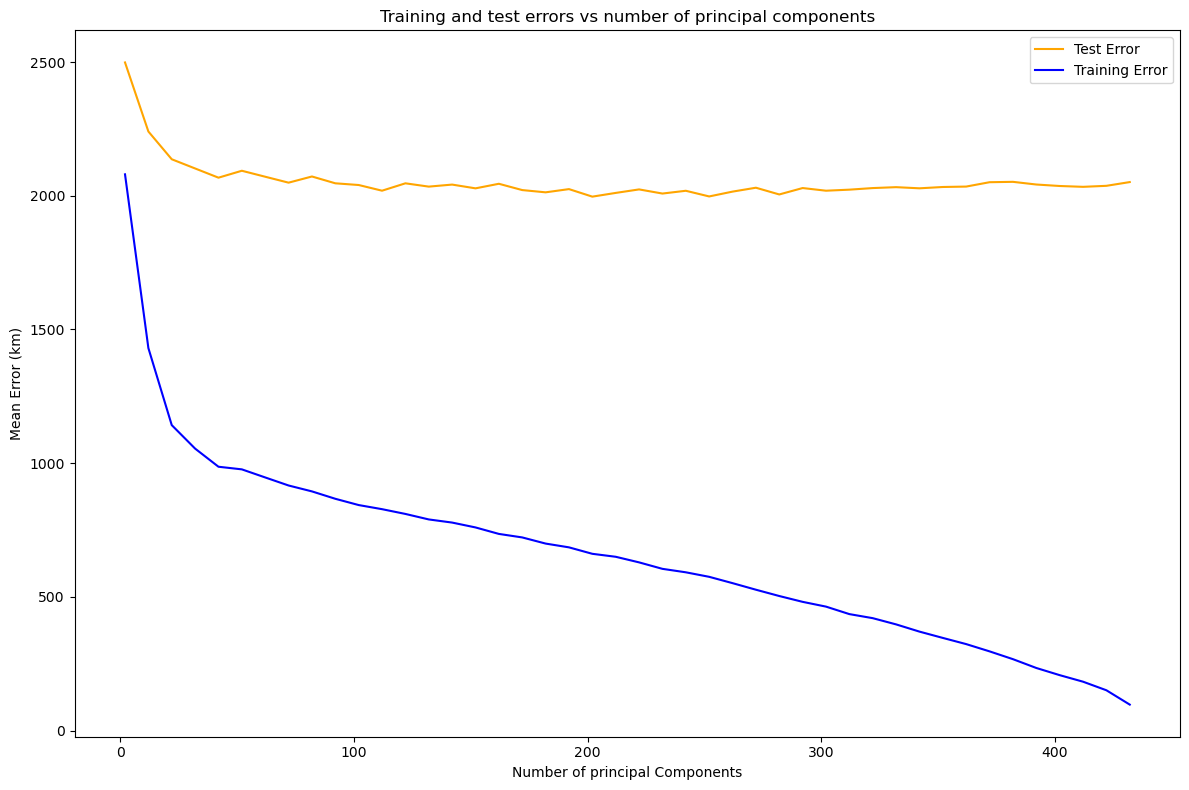

In [20]:
train_error = []
test_error = []

for n in range(2, 440, 10):
    pca = PCA(n_components = n)

    # Here, we use ten-fold cross validation
    groups = df["Pop"].values
    group_fold = GroupKFold(n_splits = 10)
    
    # Pipeline
    pipeline = make_pipeline(pca, LinearRegression())
    
    train_errors_km = []
    test_errors_km = []
    
    y_values = y.values
    
    for train_idx, test_idx in group_fold.split(X, y, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_values[train_idx], y_values[test_idx]
        
        # Fit pipeline on training fold
        pipeline.fit(X_train, y_train)
        
        # Predict on test and train fold
        y_train_pred = pipeline.predict(X_train)
        y_test_pred = pipeline.predict(X_test)
        
        # Distance in km
        y_test_radian = np.radians(y_test)
        y_test_pred_radian = np.radians(y_test_pred)
        dist_matrix_test = haversine_distances(y_test_radian, y_test_pred_radian)
        dist_km_test = np.diag(dist_matrix_test) * 6371
        test_errors_km.append(np.mean(dist_km_test))
    
        y_train_radian = np.radians(y_train)
        y_train_pred_radian = np.radians(y_train_pred)
        dist_matrix_train = haversine_distances(y_train_radian, y_train_pred_radian)
        dist_km_train = np.diag(dist_matrix_train) * 6371
        train_errors_km.append(np.mean(dist_km_train))
    
        
    
    # Overall mean error across folds
    test_mean_error_km = round(np.mean(test_errors_km), 2)
    train_mean_error_km = round(np.mean(train_errors_km), 2)

    test_error.append(test_mean_error_km)
    train_error.append(train_mean_error_km)

component = [n for n in range(2, 440, 10)]

plt.figure(figsize=(12, 8))
plt.plot(component, test_error, color="orange", label='Test Error')
plt.plot(component, train_error, color="blue", label='Training Error')
plt.xlabel('Number of principal Components')
plt.ylabel('Mean Error (km)')
plt.title('Training and test errors vs number of principal components')
plt.legend()
plt.tight_layout()

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

<span style="color:blue">
<br>

We observe that the test error curve flattens quickly. It would be more appropriate not to look for the minimum of the error, but instead looking for the point where the curve actually starts to flatten. We choose the first moment we get an error value under 1% of the minimum observed error.

<br>

<span>

In [21]:
# Get the minimum and the threshold
min_test_error = min(test_error)
threshold = min_test_error * 1.01

# Get the minimum number of principal components to reach the threshold
min_components = component[next(i for i, e in enumerate(test_error) if e <= threshold)]
mean_error_test_min_components = test_error[next(i for i, e in enumerate(component) if e == min_components)]
mean_error_train_min_components = train_error[next(i for i, e in enumerate(component) if e == min_components)]
print("\n")
print("Number of components for the best model : ",  min_components, "\n")
print("The Mean Error for test set with ", min_components, " principal components is ", mean_error_test_min_components, "\n")
print("The Mean Error for train set with ", min_components, " principal components is ", mean_error_train_min_components, "\n")
print("\n")



Number of components for the best model :  182 

The Mean Error for test set with  182  principal components is  2012.81 

The Mean Error for train set with  182  principal components is  699.19 





/var/folders/p8/pmrg399130j_1d148mx525q00000gn/T/ipykernel_1307/1096411341.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


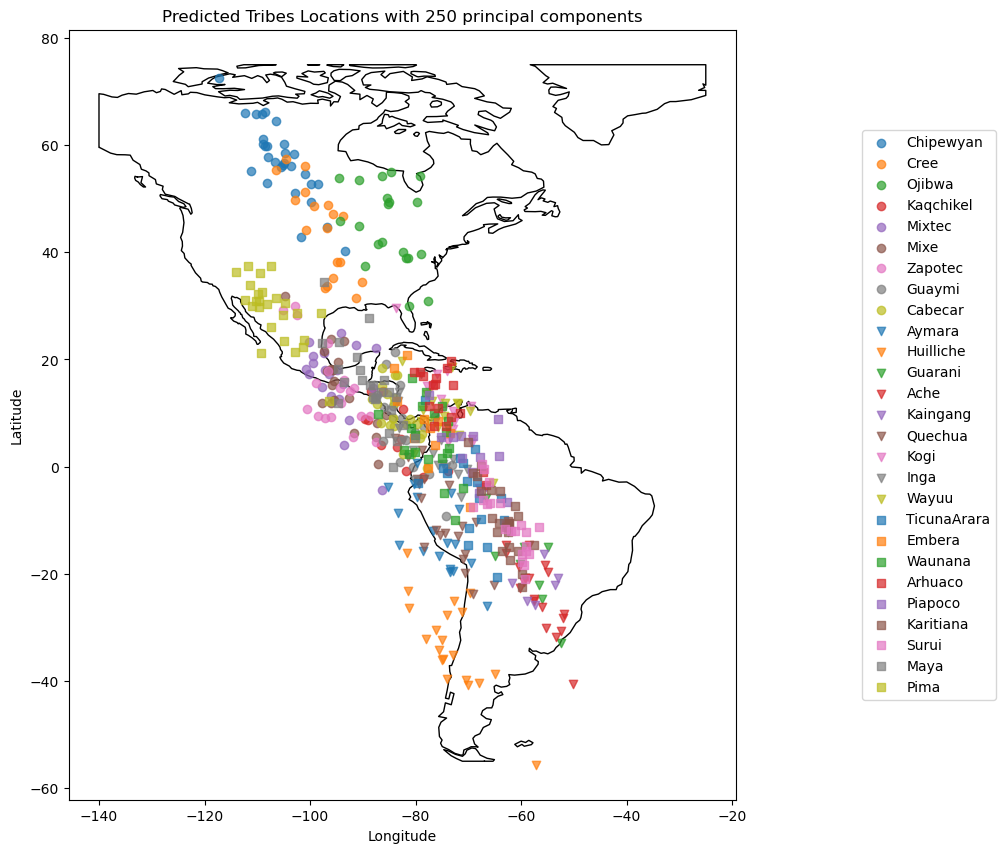

In [22]:
# PCA
pca = PCA(n_components = 132)

# Pipeline
final_model = make_pipeline(pca, LinearRegression())

final_model.fit(X, y_values)
y_pred = final_model.predict(X)

# Figure
fig, ax = plt.subplots(figsize=(10, 10))
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

for i, tribe in enumerate(df['Pop'].unique()):
    tribe_mask = df['Pop'] == tribe
    ax.scatter(
        y_pred[tribe_mask, 1],
        y_pred[tribe_mask, 0],
        marker=marker_list[i//9],
        color=colors_list[i % len(colors_list)],
        label=tribe,
        alpha=0.7
    )

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Tribes Locations with 250 principal components')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

<span style="color:blue">
<br>

We observe that the Mean Error on the test set is way higher than on the train set, which suggests that the model is probably overfitting.

Overall, this shows that while the model captures the main relationship between genetic markers and geography, it may not generalize perfectly to new individuals.

<br>

<span>

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

<span style="color:blue">
<br>

### Model Performance Analysis

In this study, we determined that a PCR model with 132 principal components provides the best results on this dataset. Even though the Mean Error is not minimized for 132 principal components, we observe a plateau beyond suggesting that adding components does not really improve the results. We also observed significant difference between testing and training results, which could be interpreted by some overfitting from the model. 

<br>

<span>

<span style="color:blue">
<br>

### Possible Improvements

We may remark that because of migration and mixing, tribes might share genetic makers, which could lead to non-linear relationships between genetic makers and precise geographic location. As a result, cross-validation could not be actually appropriate in this situation.

Possible improvements could include the use of alternative method as Partial Least Square (PLS) or non-linear model like random forests or neural networks. [Partial Least Square](https://www.mathworks.com/help/stats/partial-least-squares.html) :

> Partial least-squares (PLS) regression is a technique used with data that contain correlated predictor variables. This technique constructs new predictor variables, known as components, as linear combinations of the original predictor variables. PLS constructs these components while considering the observed response values, leading to a parsimonious model with reliable predictive power.

<br>

<span>

<span style="color:blue">
<br>

### Performance Based On Tribes

<br>

<span>

In [23]:
# We add a dist_error column to df to get the mean distance error by population
df["dist_error"] = dist_km

error_by_pop = df.groupby("Pop")["dist_error"].mean().sort_values()

print(error_by_pop)

Pop
Surui          396.587205
Wayuu          485.249331
Zapotec        497.162191
Arhuaco        509.124325
Embera         512.178525
Pima           531.369034
Piapoco        539.498603
Ache           560.789192
Mixe           576.253729
Cree           587.483524
Cabecar        590.631881
TicunaArara    597.291792
Chipewyan      601.175350
Karitiana      603.849685
Kaingang       609.830638
Inga           610.090175
Ojibwa         612.036854
Mixtec         624.067054
Kogi           678.404925
Waunana        704.843562
Guaymi         717.593564
Huilliche      749.095229
Guarani        753.993730
Quechua        765.677618
Aymara         788.078240
Maya           831.261529
Kaqchikel      903.666818
Name: dist_error, dtype: float64


/var/folders/p8/pmrg399130j_1d148mx525q00000gn/T/ipykernel_1307/3920073876.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dist_error"] = dist_km


<span style="color:blue">
<br>

We observe that the predictive performance varies significantly across tribes. Some tribes (Kaingang, Surui) have the smallest Mean Errors, while others (Kaqchikel, Guarani) show much higher errors. We may assume that tribes that share many genetic makers with other groups are harder to localize accurately, leading to larger prediction errors. 

<br>

<span>

<span style="color:blue">
<br>

### Conclusion

In this study, we observed that due to migration and other genetic mixing factors, many tribes share genetic markers. This limits the ability of linear models like PCA and PCR to accurately predict geographic locations. Cross-validation results are not good on unseen data and the predictions are likely less accurate because the model overfits to the known populations.

<br>

<span>